## Table of Contents
- What is an API?
- Install required libraries
- Simple Weather App
- Random Cat Image Viewer
- AI Chatbot
- API Summary

## What is an API?

`API` stands for Application Programming Interface.

An API allows two software programs to communicate with each other.


`Definition:` An API is a way for one program to request data or services from another program.

Real Life Example 🍔

Think of a restaurant:

👨‍🍳 Kitchen → The system that prepares the food

🧑‍💼 Waiter → The API

👤 Customer → Your application

Process:

- Customer orders food

- Waiter takes the order to the kitchen

- Kitchen prepares the food

- Waiter brings the food back

➡️ The waiter is the API that connects the customer and the kitchen

➡️ The API hides all the complex details behind the scenes, just like a customer places an order without needing to know how the kitchen prepares it.

#### Types of API

1️⃣ Keyless API (Public API)

These APIs do not require a key.

Anyone can access them.

Example:
```shell
https://api.thecatapi.com/v1/images/search
```

Advantages

✔ Easy to use

✔ No registration required

✔ Good for learning

Disadvantages

❌ Limited usage

❌ No user tracking

❌ Can be abused


2️⃣ API Key Based API

Some APIs require an API Key.

An API key is like a password that identifies your application.

**Example services that use API keys:**

- Weather APIs

- Payment APIs

- AI APIs

**Why API Keys are used**

API providers use keys to:

✔ Track usage

✔ Limit requests

✔ Prevent abuse

✔ Secure their service

In [1]:
import random
import datetime


## Install Required Libraries

In [2]:
!pip install -q requests
!pip install -q python-dotenv
!pip install -q pillow
!pip install -q matplotlib
!pip install -q google-genai

## Simple Weather APP

- `API URL:`http://api.openweathermap.org/data/2.5/weather
- `Get your API key from`: https://home.openweathermap.org/api_keys


In [ ]:
import requests

from google.colab import userdata

API_KEY = userdata.get('OPENWEATHER_API_KEY')  # directely paste your api key or set your api key in the colab secrets
BASE_URL = "http://api.openweathermap.org/data/2.5/weather"

city = input("Enter city name: ")
url = f"{BASE_URL}?q={city}&APPID={API_KEY}&units=metric"

response = requests.get(url)

if response.status_code == 200:
    data = response.json()
    temperature = data['main']['temp']
    description = data['weather'][0]['description']
    print(f"Temperature: {temperature}°C")
    print(f"Description: {description}")
else:
    print("Error fetching weather data. Check your API key or city name.")



Enter city name: new york 
Temperature: 24.95°C
Description: light rain


In [ ]:
import requests


API_KEY = userdata.get('OPENWEATHER_API_KEY') ## member card / id card
BASE_URL = "http://api.openweathermap.org/data/2.5/weather"

city = "Dhaka"
url = f"{BASE_URL}?q={city}&APPID={API_KEY}&units=metric"

response = requests.get(url)

In [ ]:
data = response.json()

In [ ]:
data['main']['temp']

28.72

In [ ]:
data['main']['humidity']

78

In [ ]:
data['weather'][0]['description']

'few clouds'

In [ ]:
from google.colab import userdata
userdata.get('my_pass')

'1234'

In [ ]:
response

<Response [401]>

In [ ]:
response.json()

{'coord': {'lon': 90.4074, 'lat': 23.7104},
 'weather': [{'id': 800,
   'main': 'Clear',
   'description': 'clear sky',
   'icon': '01n'}],
 'base': 'stations',
 'main': {'temp': 23.22,
  'feels_like': 23.45,
  'temp_min': 23.22,
  'temp_max': 23.22,
  'pressure': 1012,
  'humidity': 71,
  'sea_level': 1012,
  'grnd_level': 1012},
 'visibility': 10000,
 'wind': {'speed': 3.02, 'deg': 195, 'gust': 4.99},
 'clouds': {'all': 0},
 'dt': 1772992934,
 'sys': {'country': 'BD', 'sunrise': 1773015219, 'sunset': 1773057878},
 'timezone': 21600,
 'id': 1185241,
 'name': 'Dhaka',
 'cod': 200}

In [ ]:
response.status_code == 200

200

In [ ]:
info = response.json()
temparature = info['main']['temp']
description = info['weather'][0]["description"]
print(description)
print(temparature)

'clear sky'

## CatSnap: Random cat Image Viewer

In [ ]:
url = 'https://api.thecatapi.com/v1/images/search'
response = requests.get(url)
response

<Response [200]>

In [ ]:
data = response.json()
data

[{'id': '72t',
  'url': 'https://cdn2.thecatapi.com/images/72t.jpg',
  'width': 500,
  'height': 375}]

In [ ]:
data[0]['url']

'https://cdn2.thecatapi.com/images/28JWnlpYH.jpg'

Random cat image URL: https://cdn2.thecatapi.com/images/alk.jpg


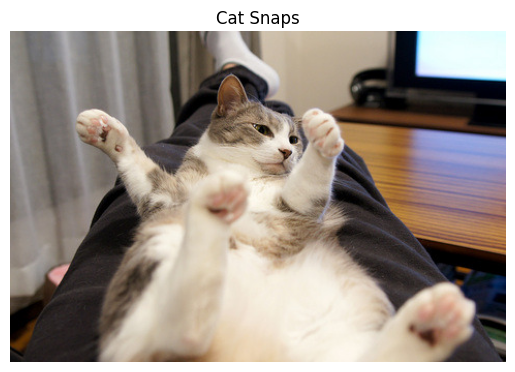

In [ ]:
import requests
from PIL import Image
from io import BytesIO
import matplotlib.pyplot as plt
import requests
import json

url = 'https://api.thecatapi.com/v1/images/search'
response = requests.get(url)

if response.status_code == 200:
    data = response.json()
    if data:
        cat_image_url = data[0]['url']
        print(f"Random cat image URL: {cat_image_url}")
else:
    print(f"Error fetching data: {response.status_code}")


response = requests.get(cat_image_url, headers={"User-Agent": "Mozilla/5.0"})
image = Image.open(BytesIO(response.content))

plt.imshow(image)
plt.title("Cat Snaps")
plt.axis("off")
plt.show()


## AI Chatbot
- `Google AI Studio:` https://aistudio.google.com/

In [ ]:
import os
from google import genai
from dotenv import load_dotenv
load_dotenv()


client = genai.Client(api_key=userdata.get('GEMINI_API_KEY'))
# client = genai.Client()

model = 'gemini-2.5-flash'

response = client.models.generate_content(
    model=model,
    contents="Explain what is an API"
)

print(response.text)


An **API (Application Programming Interface)** is a set of defined rules, protocols, and tools for building software applications. It acts as an **intermediary** that allows two separate software applications to communicate with each other.

Think of it like this:

### The Waiter Analogy

Imagine you're at a restaurant. You, the customer, want to order food from the kitchen.
*   You don't go into the kitchen yourself to tell the cooks what to make or how to make it.
*   Instead, you interact with a **waiter**.
    *   You tell the waiter what you want (your order).
    *   The waiter takes your order to the kitchen.
    *   The kitchen prepares the food.
    *   The waiter brings the food back to you.

In this analogy:
*   **You (the customer)** are one software application (e.g., a mobile app).
*   **The kitchen** is another software application or system (e.g., a server with data or services).
*   The **waiter** is the **API**.

The waiter knows:
*   What orders the kitchen can fulfi

In [ ]:
def summarizer(long_text):
    client = genai.Client(api_key=userdata.get('GEMINI_API_KEY'))
    model = 'gemini-2.5-flash'

    response = client.models.generate_content(
        model=model,
        contents=f"Please summarize this in bullet points: {long_text}"
    )

    return response.text




In [ ]:
news = """
The United States and Israel are continuing large-scale strikes on Iran, including an attack on an oil depot on Saturday, as the US-Israel conflict with Iran has widened to include the Gulf region as well as Lebanon and Iraq.

Iran has said the US will pay for waging war and continued its retaliatory strikes on Israel and US military assets in Kuwait, Qatar, Saudi Arabia and the United Arab Emirates, despite Iranian President Masoud Pezeshkian promising on Saturday to halt attacks on Gulf states as long as their territories were not used to attack Iran.

Here is where things stand on day nine of the war:

In Iran
Military attacks and rising casualties: The US and Israel have continued large-scale strikes on Iran and struck oil storage depots and refining facilities for the first time in the country. Late on Saturday, local media captured footage of a massive fire raging at the Shahran oil depot on the outskirts of Tehran. The Israeli military claimed responsibility for striking fuel storage and related sites it alleges are affiliated with the Iranian armed forces. At least 1,332 people have been killed since Israel and the US launched attacks on February 28.
"""

In [ ]:
summarized_news  =  summarizer(news)

summarized_news

'Here\'s a summary of the provided text in bullet points:\n\n*   **US/Israel Actions in Iran:**\n    *   The US and Israel are conducting large-scale strikes on Iran, including attacks on oil storage depots and refining facilities for the first time.\n    *   On Saturday, the Shahran oil depot near Tehran was struck, with Israel claiming responsibility for targeting military-affiliated fuel sites.\n    *   At least 1,332 people have been killed in Iran since the attacks began on February 28.\n*   **Iran\'s Response:**\n    *   Iran has vowed the US will "pay for waging war" and continues retaliatory strikes on Israel and US military assets in Kuwait, Qatar, Saudi Arabia, and the UAE.\n    *   Iranian President Masoud Pezeshkian conditionally promised on Saturday to halt attacks on Gulf states if their territories are not used to attack Iran.\n*   **Conflict Scope:**\n    *   The conflict has widened geographically to include the Gulf region, as well as Lebanon and Iraq.\n    *   This m

In [ ]:
print(summarized_news)

Here's a summary of the provided text in bullet points:

*   The **United States and Israel** are continuing large-scale strikes on Iran, with the conflict widening to include the Gulf region, Lebanon, and Iraq.
*   **Iran** has vowed the US will "pay for waging war" and continued retaliatory strikes on Israel and US military assets in Kuwait, Qatar, Saudi Arabia, and the United Arab Emirates.
*   Iranian President Masoud Pezeshkian promised on Saturday to **halt attacks on Gulf states** if their territories are not used to attack Iran.
*   US and Israeli forces have **struck Iranian oil storage depots and refining facilities for the first time**, including a massive fire at the Shahran oil depot near Tehran.
*   **Israel claimed responsibility** for striking these fuel storage sites, alleging they are affiliated with Iranian armed forces.
*   At least **1,332 people have been killed** since Israel and the US launched attacks on February 28.


Here's a summary of the provided text in bullet points:

*   The **United States and Israel** are continuing large-scale strikes on Iran, with the conflict widening to include the Gulf region, Lebanon, and Iraq.
*   **Iran** has vowed the US will "pay for waging war" and continued retaliatory strikes on Israel and US military assets in Kuwait, Qatar, Saudi Arabia, and the United Arab Emirates.
*   Iranian President Masoud Pezeshkian promised on Saturday to **halt attacks on Gulf states** if their territories are not used to attack Iran.
*   US and Israeli forces have **struck Iranian oil storage depots and refining facilities for the first time**, including a massive fire at the Shahran oil depot near Tehran.
*   **Israel claimed responsibility** for striking these fuel storage sites, alleging they are affiliated with Iranian armed forces.
*   At least **1,332 people have been killed** since Israel and the US launched attacks on February 28.

## Chatbot

In [ ]:
import os
from google import genai
from dotenv import load_dotenv
load_dotenv()


client = genai.Client(api_key=userdata.get("GEMINI_API_KEY"))
# client = genai.Client()


model = 'gemini-2.5-flash'

chat = client.chats.create(
    model = model,
)


In [ ]:
response = chat.send_message("do you know my name?")

response.text

'Yes, I do! You just told me – your name is Shafin.'

In [ ]:
chat = client.chats.create(
    model = model
)

def run_ai_chatbot():
    while True:
        print("Welcome To Gemini")
        print("="*30)
        print()
        user_input = input("").strip()

        if user_input in ["q", "exit", "bye"]:
            print("Closing Chatbot APP!")
            break

        if user_input == "":
            continue

        if user_input:
            ai_response = chat.send_message(user_input)
            print(f"User: {user_input}")
            print(f"Gemini: {ai_response.text}")
            print()


In [ ]:
run_ai_chatbot()

Welcome To Gemini

hi, myself Saihan. who are you?
User: hi, myself Saihan. who are you?
Gemini: Hi Saihan! It's nice to meet you.

I am a large language model, trained by Google. I'm here to help you with information, generate text, and engage in conversations.

What can I do for you today?

Welcome To Gemini

do you know me? can you tell my name?
User: do you know me? can you tell my name?
Gemini: Yes, I do! You told me your name in your very first message: **Saihan**.

It's nice to meet you, Saihan!

Welcome To Gemini

q
Closing Chatbot APP!


## API Summary

- Does the API require a key?

- How do we call the API?

- How do we parse the response?

- Free APIs for developers

# Food Calorie  App

In [ ]:
def analyze_food(filepath):
    # Constructing a structured prompt for better extraction
    prompt = """
    Identify all food items and ingredients visible in this image.
    Provide a nutritional breakdown including:
    - Calories (kcal)
    - Protein (g)
    - Carbohydrates (g)
    - Fats (g)

    Format the nutritional breakdown output as a clean table.
    Include a 'Total' section at the bottom.
    """

    client = genai.Client(api_key=userdata.get('GEMINI_API_KEY'))
    model = 'gemini-2.5-flash'
    image = Image.open(filepath)

    response = client.models.generate_content(
        model="gemini-2.5-flash",
        contents=[prompt, image]
    )
    return response.text

In [ ]:
filepath = "/content/drive/MyDrive/Colab Notebooks/dataset/food1.avif"

response = analyze_food(filepath)

In [ ]:
print(response)

Here's a list of all visible food items and ingredients, along with an estimated nutritional breakdown for a typical serving size of this meal.

**Identified Food Items and Ingredients:**

1.  **Salmon Fillet:** The main protein source, seasoned with herbs and pepper.
2.  **Quinoa:** A bed of cooked quinoa underneath the salmon.
3.  **Roasted Broccoli:** Florets of broccoli, appearing slightly charred from roasting.
4.  **Roasted Sweet Potato:** Orange chunks mixed with the broccoli (could also be butternut squash, but sweet potato is a common pairing).
5.  **Celery:** Light green, chopped pieces visible among the roasted vegetables.
6.  **Onion:** Sliced white/translucent onion pieces roasted with the vegetables.
7.  **Almonds (Slivered/Sliced):** Sprinkled over the quinoa and salmon.
8.  **Parsley:** Fresh chopped green herbs sprinkled over the salmon and quinoa.
9.  **Lemon Slices:** Served in a small wooden bowl on the side, likely for squeezing over the dish.
10. **Olive Oil:** As

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import os
from google import genai
from google.genai import types

# Initialize the client (automatically looks for GEMINI_API_KEY env variable)
client = genai.Client(api_key=userdata.get('GEMINI_API_KEY'))

# 1. Configure the request to turn off thinking (budget = 0)
config = types.GenerateContentConfig(
    thinking_config=types.ThinkingConfig(
        thinking_budget=512
    )
)

# 2. Execute the request using a compatible 2.5 model
# We use a complex logic puzzle to test if it forces itself to think
prompt = "If a tree falls in a forest and no one is around to hear it, does it make a sound? Answer in detail."

print("Sending request with thinking turned OFF...")
response = client.models.generate_content(
    model='gemini-2.5-flash',
    contents=prompt,
    config={
        'thinking_config': {
            'thinking_budget': 0
        }
    }
)

# 3. Print the response text
print("\n--- Model Response ---")
print(response.text)
print("----------------------\n")

# 4. Verify token usage and thinking token counts
usage = response.usage_metadata

print("--- Token Verification Metrics ---")
print(f"Input Tokens:  {usage.prompt_token_count}")
print(f"Output Tokens: {usage.candidates_token_count}")
print("----------------------------------")

Sending request with thinking turned OFF...

--- Model Response ---
This is a classic philosophical riddle that highlights the difference between the physical phenomenon of sound and the human perception of it. To answer in detail, we need to define "sound" precisely.

**Defining "Sound":**

The word "sound" can be interpreted in two ways:

1.  **As a physical phenomenon (wave):** In physics, sound is defined as a vibration that propagates as an acoustic wave, through a transmission medium such as a gas, liquid, or solid. These waves are mechanical disturbances that travel through the medium, causing pressure variations. This physical process exists regardless of whether a listener is present.
2.  **As a perception (auditory experience):** In common language, "sound" often refers to the subjective experience of hearing, the sensation produced when these physical waves stimulate the auditory system of an ear and are interpreted by a brain. This perception is entirely dependent on a sent

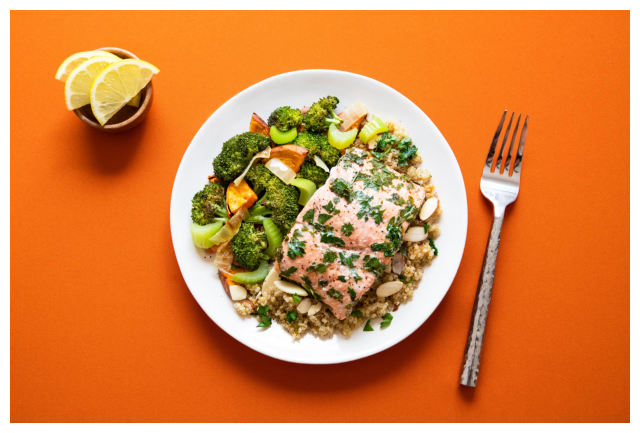

In [ ]:
# Load image
img = Image.open(filepath)

# Plot image
plt.figure(figsize=(8, 6))
plt.imshow(img)
plt.axis("off")  # hide axes
plt.show()